In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [44]:
data_dir = r"C:\Users\igles\Downloads\MOR\banana dataset"

batch_size = 16
img_height = 180
img_width = 180

In [45]:

# 2. LOAD DATA
# ==========================================================
print("Loading Data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='binary'
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)




Loading Data...
Found 7814 files belonging to 2 classes.
Using 6252 files for training.
Found 7814 files belonging to 2 classes.
Using 1562 files for validation.


In [46]:
# 3. BUILD STABILIZED MODEL (Anti-Overfitting)
# ==========================================================



inputs = keras.Input(shape=(img_height, img_width, 3))


# Rescaling
x = layers.Rescaling(1./255)(inputs)

# 2. CONVOLUTIONAL BASE (Simplified Depth)
# Block 1
x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 2
x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 3
x = layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 4 (Only one block of 512 filters now)
x = layers.Conv2D(512, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling2D()(x)

# 3. CLASSIFICATION HEAD (Heavy Dropout)
x = layers.Dropout(0.7)(x) # High dropout to prevent overfitting
outputs = layers.Dense(1, activation='sigmoid',
                       kernel_regularizer=regularizers.l2(0.01))(x)

model = keras.Model(inputs, outputs)

# 4. COMPILE (Lower Learning Rate)
# A lower LR reduces the "spiking" in validation loss
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [47]:
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling_5 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_19 (Conv2D)          (None, 180, 180, 64)      1792      
                                                                 
 batch_normalization_14 (Bat  (None, 180, 180, 64)     256       
 chNormalization)                                                
                                                                 
 activation_14 (Activation)  (None, 180, 180, 64)      0         
                                                                 
 max_pooling2d_15 (MaxPoolin  (None, 90, 90, 64)       0         
 g2D)                                                      

In [48]:
# 4. COMPILE
# ==========================================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# 5. TRAIN
# ==========================================================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

epochs = 20
print(f"\nStarting Training...")

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[early_stop, reduce_lr]
)


Starting Training...
Epoch 1/20


391/391 [==============================] - 71s 85ms/step - loss: 6.3007 - accuracy: 0.7260 - val_loss: 6.2996 - val_accuracy: 0.5122 - lr: 1.0000e-05
Epoch 2/20
391/391 [==============================] - 25s 65ms/step - loss: 5.5978 - accuracy: 0.7978 - val_loss: 5.2252 - val_accuracy: 0.8700 - lr: 1.0000e-05
Epoch 3/20
391/391 [==============================] - 25s 64ms/step - loss: 5.0340 - accuracy: 0.8258 - val_loss: 4.8575 - val_accuracy: 0.7746 - lr: 1.0000e-05
Epoch 4/20
391/391 [==============================] - 25s 64ms/step - loss: 4.5548 - accuracy: 0.8440 - val_loss: 4.3420 - val_accuracy: 0.8355 - lr: 1.0000e-05
Epoch 5/20
391/391 [==============================] - 25s 64ms/step - loss: 4.1500 - accuracy: 0.8578 - val_loss: 4.1010 - val_accuracy: 0.7740 - lr: 1.0000e-05
Epoch 6/20
391/391 [==============================] - 24s 62ms/step - loss: 3.7923 - accuracy: 0.8714 - val_loss: 3.5888 - val_accuracy: 0.8873 - lr: 1.0000e-05
Epoch 7/20
391/391 [=========================


Final Evaluation:
98/98 [==============================] - 1s 13ms/step - loss: 1.8233 - accuracy: 0.9027
Final Validation Accuracy: 90.27%


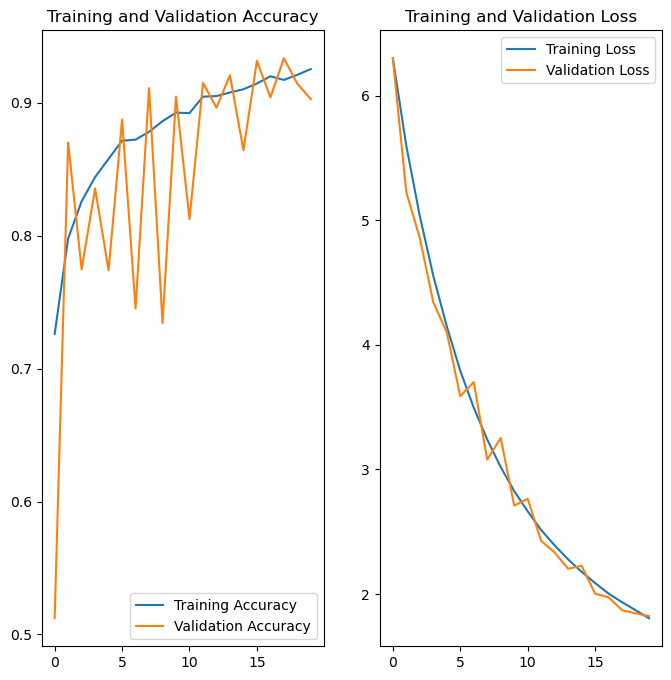

In [49]:
# 6. EVALUATE
# ==========================================================
print("\nFinal Evaluation:")
loss, accuracy = model.evaluate(val_ds)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

# Plotting
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss_vals = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss_vals, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [50]:
def check_image(image_path):

    img_height = 180
    img_width = 180

    # Load image
    img = tf.keras.utils.load_img(image_path)
    img = tf.keras.utils.img_to_array(img)

    # Resize
    img = tf.image.resize(img, [img_height, img_width])

    # Prepare for model
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, 0)   # IMPORTANT

    # Predict
    prediction = model.predict(img)
    score = prediction[0][0]

    if score < 0.5:
        print("Prediction: With Carbide")
    else:
        print("Prediction: Without Carbide")

In [53]:
# Run this to test
test_image_path = r'C:\Users\igles\Downloads\MOR\banana dataset\Without Carbide\549.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 14ms/step
Prediction: Without Carbide


In [54]:
# Run this to test
test_image_path = r'C:\Users\igles\Downloads\MOR\banana dataset\With Carbide\24.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 13ms/step
Prediction: With Carbide


In [55]:
# Run this to test
test_image_path = r'C:\Users\igles\MORTEAM13\test4.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 20ms/step
Prediction: Without Carbide


In [56]:
# Run this to test
test_image_path = r"C:\Users\igles\Downloads\1234.jpg"
check_image(test_image_path)

1/1 [==============================] - 0s 15ms/step
Prediction: With Carbide
